# Notebook 05 · Data Cataloging & Data Contracts
## From Undocumented Assets to Trusted Data Products

**Nisrina Afnan Walyadin** · MSc Mathematics, TU Munich  
*nisrinawalyadin@gmail.com · Munich, Germany*

---

### Overview

This notebook demonstrates a **production-grade Data Cataloging and Contract Validation framework** — a core competency in modern data engineering and analytics roles.

The framework is applied to **real U.S. property-casualty insurance loss data** from the Casualty Actuarial Society (CAS), covering two lines of business:
- **Other Liability** — occurrence-based commercial liability losses
- **Commercial Auto** — truck and commercial vehicle liability losses

The same patterns apply across industries wherever data governance matters: insurance, reinsurance, banking, healthcare, retail, logistics.

---

### Data Source

> **Casualty Actuarial Society (CAS) — Loss Reserving Data**  
> *Loss Reserving Data Pulled from NAIC Schedule P with Additional Accident Years*  
> Published by the CAS Reserve Research Working Group.  
> Data compiled by S&P Global Market Intelligence.  
> Source: [https://www.casact.org/publications-research/research/research-resources/loss-reserving-data-pulled-naic-schedule-p](https://www.casact.org/publications-research/research/research-resources/loss-reserving-data-pulled-naic-schedule-p)  
> Updated: December 2025. Freely available under CAS open data policy.
>
> The dataset contains run-off loss triangles from NAIC Schedule P — Analysis of Losses and Loss Expenses — for U.S. property-casualty insurers. Accident years 1998–2007, 10 development lags per insurer.

---

### What This Notebook Demonstrates

| Competency | Method |
|---|---|
| **Exploratory Data Analysis** | Real loss triangle profiling, null analysis, distribution review |
| **Data Cataloging** | Automated metadata extraction & asset registry |
| **Data Contracts** | Schema definitions, SLA thresholds, ownership |
| **Data Lineage** | Source → Transform → Consume mapping |
| **Contract Validation** | Rule engine with PASS / BLOCK pipeline gate |
| **Loss Triangle Analysis** | Chain-ladder development factors (actuarial standard) |
| **BI Summary** | Insurer-level KPI dashboard |

---


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json, warnings
from datetime import datetime
from dataclasses import dataclass, field, asdict
from typing import List, Dict, Optional

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: f'{x:,.1f}')

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#2e3250',   'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',      'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',       'grid.color': '#21262d',
    'grid.linestyle': '--',        'font.family': 'monospace',
})
ACCENT, GREEN, ORANGE, RED, PURPLE = '#58a6ff','#3fb950','#f0883e','#f85149','#bc8cff'

print("✅ Imports ready")
print("Data source: CAS Loss Reserving Data — NAIC Schedule P (Updated December 2025)")


✅ Imports ready
Data source: CAS Loss Reserving Data — NAIC Schedule P (Updated December 2025)


---
## 1 · Load & Explore Real Data

We load two lines of business from the CAS Schedule P dataset:

| Dataset | Line of Business | Rows | Insurers | Period |
|---|---|---|---|---|
| `othliab` | Other Liability (occurrence) | 22,020 | 236 | 1998–2007 |
| `comauto` | Commercial Auto / Truck | 14,640 | 157 | 1998–2007 |

Each row represents one insurer × one accident year × one development lag (1–10 years).  
This **loss triangle** structure is fundamental to insurance reserving and actuarial analysis.


In [ ]:
# ── Load real CAS Schedule P data ────────────────────────────────────────────
othliab = pd.read_csv('../data/othliab_pos_98-07.csv') #tanggungan gugat umum
comauto = pd.read_csv('../data/comauto_pos_98-07.csv') #asuransi kendaraan komersial

# Add line-of-business label
othliab['LineOfBusiness'] = 'Other Liability'
comauto['LineOfBusiness'] = 'Commercial Auto'

datasets = {'othliab': othliab, 'comauto': comauto}

for name, df in datasets.items():
    print(f"{'='*55}")
    print(f"  {name.upper()}  —  {df['LineOfBusiness'].iloc[0]}")
    print(f"{'='*55}")
    print(f"  Shape        : {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"  Insurers     : {df['GRCODE'].nunique()} unique (GRCODE)")
    print(f"  Accident Yrs : {df['AccidentYear'].min()} – {df['AccidentYear'].max()}")
    print(f"  Dev Lags     : {df['DevelopmentLag'].min()} – {df['DevelopmentLag'].max()}")
    print(f"  Null values  : {df.isnull().sum().sum()}")
    print(f"  Memory       : {df.memory_usage(deep=True).sum()/1e6:.2f} MB")
    print()


  OTHLIAB  —  Other Liability
  Shape        : 22,020 rows × 14 columns
  Insurers     : 236 unique (GRCODE)
  Accident Yrs : 1998 – 2007
  Dev Lags     : 1 – 10
  Null values  : 0
  Memory       : 5.44 MB

  COMAUTO  —  Commercial Auto
  Shape        : 14,640 rows × 14 columns
  Insurers     : 157 unique (GRCODE)
  Accident Yrs : 1998 – 2007
  Dev Lags     : 1 – 10
  Null values  : 0
  Memory       : 3.61 MB



In [18]:
othliab

,GRCODE,GRNAME,AccidentYear,DevelopmentYear,DevelopmentLag,IncurredLosses,CumPaidLoss,BulkLoss,EarnedPremDIR,EarnedPremCeded,EarnedPremNet,Single,PostedReserves2007,LineOfBusiness
0,337,California Cas Grp,1998,1998,1,0,0,0,0,0,0,0,6.4,Other Liability
1,337,California Cas Grp,1998,1999,2,0,0,0,0,0,0,0,6.4,Other Liability
2,337,California Cas Grp,1998,2000,3,0,0,0,0,0,0,0,6.4,Other Liability
3,337,California Cas Grp,1998,2001,4,0,0,0,0,0,0,0,6.4,Other Liability
4,337,California Cas Grp,1998,2002,5,0,0,0,0,0,0,0,6.4,Other Liability
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22015,44598,College Liability Ins Co Ltd RRG,2007,2012,6,70,69,1,499,0,499,1,"1,160.4",Other Liability
22016,44598,College Liability Ins Co Ltd RRG,2007,2013,7,69,69,0,499,0,499,1,"1,160.4",Other Liability
22017,44598,College Liability Ins Co Ltd RRG,2007,2014,8,69,69,0,499,0,499,1,"1,160.4",Other Liability
22018,44598,College Liability Ins Co Ltd RRG,2007,2015,9,69,69,0,499,0,499,1,"1,160.4",Other Liability


In [17]:
datasets

{'othliab':        GRCODE                            GRNAME  AccidentYear  \
 0         337                California Cas Grp          1998   
 1         337                California Cas Grp          1998   
 2         337                California Cas Grp          1998   
 3         337                California Cas Grp          1998   
 4         337                California Cas Grp          1998   
 ...       ...                               ...           ...   
 22015   44598  College Liability Ins Co Ltd RRG          2007   
 22016   44598  College Liability Ins Co Ltd RRG          2007   
 22017   44598  College Liability Ins Co Ltd RRG          2007   
 22018   44598  College Liability Ins Co Ltd RRG          2007   
 22019   44598  College Liability Ins Co Ltd RRG          2007   
 
        DevelopmentYear  DevelopmentLag  IncurredLosses  CumPaidLoss  BulkLoss  \
 0                 1998               1               0            0         0   
 1                 1999        

---
## 2 · Exploratory Data Analysis

Before building any catalog or contract, we profile the data:
- Loss distributions (highly skewed — typical for insurance data)
- Premium vs loss ratios
- Development patterns across accident years


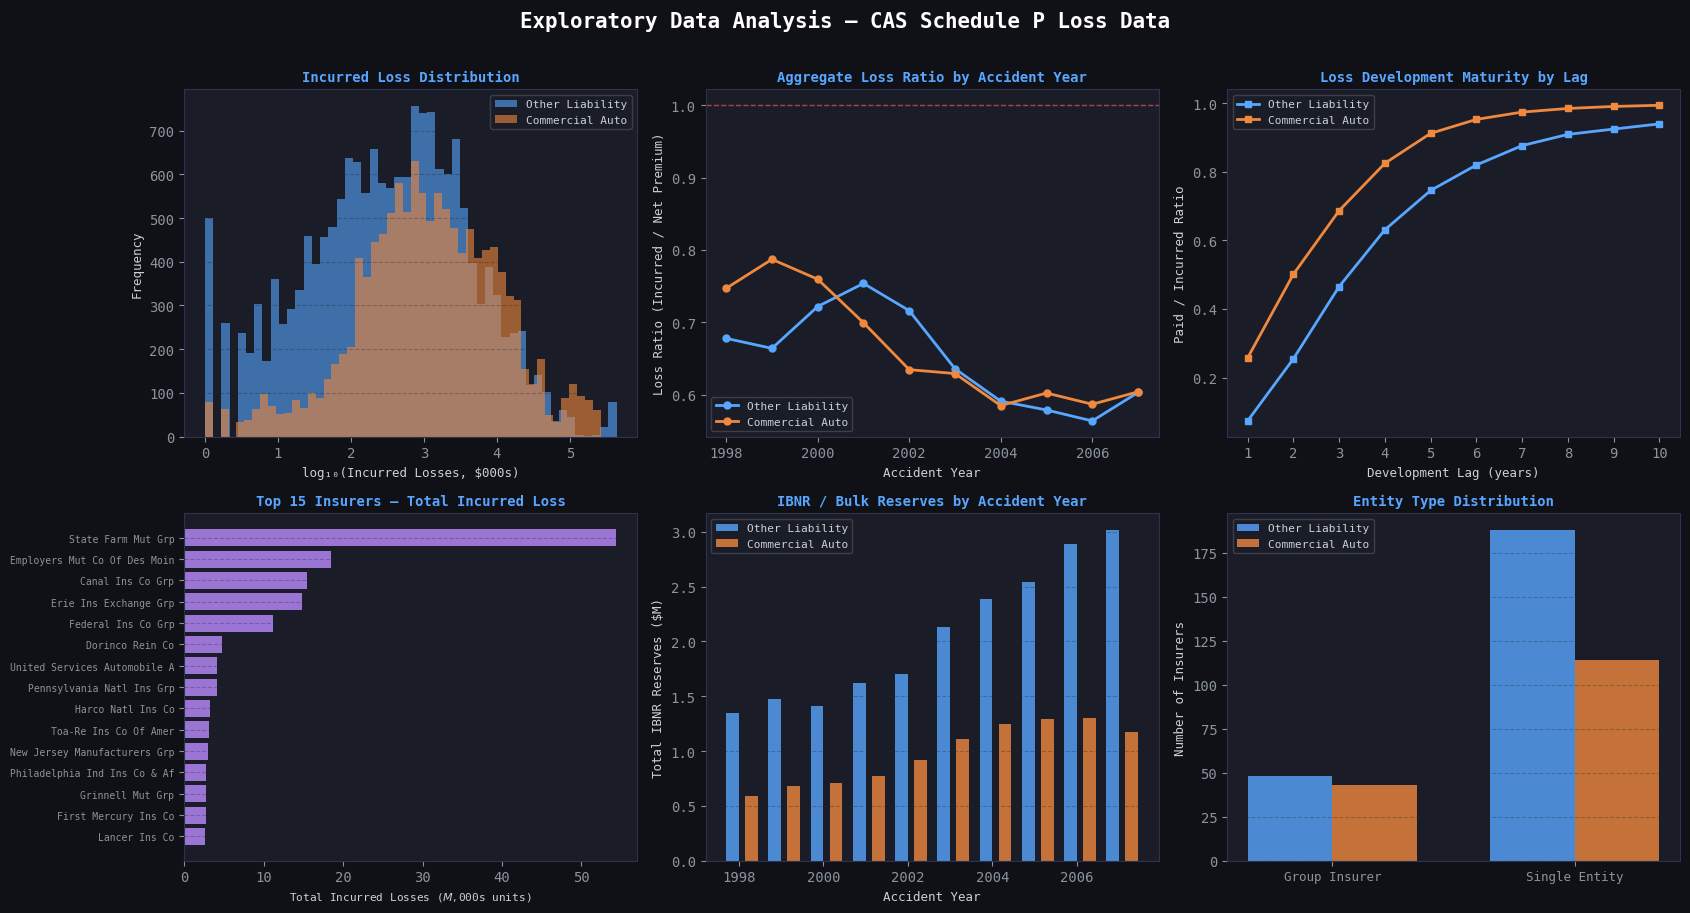

✅ EDA dashboard saved


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9), facecolor='#0f1117')
fig.suptitle('Exploratory Data Analysis — CAS Schedule P Loss Data',
             fontsize=15, fontweight='bold', color='white', y=1.01)

colors_lob = {'Other Liability': ACCENT, 'Commercial Auto': ORANGE}

# ── A: Incurred loss distribution (log scale) ─────────────────────────────────
ax = axes[0, 0]
for name, df in datasets.items():
    pos = df[df['IncurredLosses'] > 0]['IncurredLosses']
    ax.hist(np.log10(pos), bins=50, alpha=0.6,
            color=colors_lob[df['LineOfBusiness'].iloc[0]],
            label=df['LineOfBusiness'].iloc[0])
ax.set_xlabel('log₁₀(Incurred Losses, $000s)', fontsize=9)
ax.set_ylabel('Frequency', fontsize=9)
ax.set_title('Incurred Loss Distribution', fontsize=10, color=ACCENT, fontweight='bold')
ax.legend(fontsize=8, framealpha=0.2)

# ── B: Loss ratio by accident year ────────────────────────────────────────────
ax = axes[0, 1]
for name, df in datasets.items():
    ag = df[df['EarnedPremNet'] > 0].groupby('AccidentYear').apply(
        lambda x: x['IncurredLosses'].sum() / x['EarnedPremNet'].sum()
    ).reset_index(name='LossRatio')
    ax.plot(ag['AccidentYear'], ag['LossRatio'],
            marker='o', markersize=5, linewidth=2,
            color=colors_lob[df['LineOfBusiness'].iloc[0]],
            label=df['LineOfBusiness'].iloc[0])
ax.axhline(y=1.0, color=RED, linestyle='--', linewidth=1, alpha=0.7)
ax.set_xlabel('Accident Year', fontsize=9)
ax.set_ylabel('Loss Ratio (Incurred / Net Premium)', fontsize=9)
ax.set_title('Aggregate Loss Ratio by Accident Year', fontsize=10, color=ACCENT, fontweight='bold')
ax.legend(fontsize=8, framealpha=0.2)

# ── C: Development lag — paid loss maturity ───────────────────────────────────
ax = axes[0, 2]
for name, df in datasets.items():
    dg = df[df['IncurredLosses'] > 0].groupby('DevelopmentLag').apply(
        lambda x: x['CumPaidLoss'].sum() / x['IncurredLosses'].sum()
    ).reset_index(name='PaidRatio')
    ax.plot(dg['DevelopmentLag'], dg['PaidRatio'],
            marker='s', markersize=5, linewidth=2,
            color=colors_lob[df['LineOfBusiness'].iloc[0]],
            label=df['LineOfBusiness'].iloc[0])
ax.set_xlabel('Development Lag (years)', fontsize=9)
ax.set_ylabel('Paid / Incurred Ratio', fontsize=9)
ax.set_title('Loss Development Maturity by Lag', fontsize=10, color=ACCENT, fontweight='bold')
ax.legend(fontsize=8, framealpha=0.2)
ax.set_xticks(range(1, 11))

# ── D: Top 15 insurers by total incurred loss ────────────────────────────────
ax = axes[1, 0]
combined = pd.concat([othliab, comauto])
top15 = (combined.groupby('GRNAME')['IncurredLosses']
         .sum().nlargest(15).sort_values())
bars = ax.barh(range(len(top15)), top15.values / 1e6, color=PURPLE, alpha=0.8)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels([n[:28] for n in top15.index], fontsize=7)
ax.set_xlabel('Total Incurred Losses ($M, $000s units)', fontsize=8)
ax.set_title('Top 15 Insurers — Total Incurred Loss', fontsize=10, color=ACCENT, fontweight='bold')

# ── E: Bulk/IBNR reserves by accident year ───────────────────────────────────
ax = axes[1, 1]
for name, df in datasets.items():
    ag = df.groupby('AccidentYear')['BulkLoss'].sum() / 1e6
    ax.bar(ag.index + (0.3 if name == 'comauto' else -0.15), ag.values,
           width=0.3, alpha=0.8,
           color=colors_lob[df['LineOfBusiness'].iloc[0]],
           label=df['LineOfBusiness'].iloc[0])
ax.set_xlabel('Accident Year', fontsize=9)
ax.set_ylabel('Total IBNR Reserves ($M)', fontsize=9)
ax.set_title('IBNR / Bulk Reserves by Accident Year', fontsize=10, color=ACCENT, fontweight='bold')
ax.legend(fontsize=8, framealpha=0.2)

# ── F: Single entity vs group ────────────────────────────────────────────────
ax = axes[1, 2]
for i, (name, df) in enumerate(datasets.items()):
    grp = df.drop_duplicates('GRCODE')['Single'].value_counts()
    labels = ['Group Insurer', 'Single Entity']
    vals   = [grp.get(0, 0), grp.get(1, 0)]
    x      = np.arange(len(labels))
    ax.bar(x + i * 0.35, vals, width=0.35, alpha=0.8,
           color=colors_lob[df['LineOfBusiness'].iloc[0]],
           label=df['LineOfBusiness'].iloc[0])
ax.set_xticks(x + 0.175)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Number of Insurers', fontsize=9)
ax.set_title('Entity Type Distribution', fontsize=10, color=ACCENT, fontweight='bold')
ax.legend(fontsize=8, framealpha=0.2)

for ax in axes.flat:
    ax.set_facecolor('#1a1d27')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/eda_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅ EDA dashboard saved")


---
## 3 · Loss Triangle Analysis — Chain-Ladder Method

A **loss triangle** shows how losses develop over time after the accident year.  
Each row is an accident year; each column is a development lag (years since accident).

The **chain-ladder method** computes *development factors* (link ratios) between consecutive lags —  
the actuarial standard for estimating ultimate losses and IBNR reserves.

This is directly relevant to:
- **Insurance / Reinsurance**: reserve adequacy, solvency reporting
- **Data Governance**: ensuring triangle data is complete and consistent before actuarial models run


In [11]:
def build_triangle(df: pd.DataFrame, value_col: str = 'IncurredLosses') -> pd.DataFrame:
    """Pivot data into accident year × development lag triangle."""
    triangle = df.pivot_table(
        index='AccidentYear', columns='DevelopmentLag',
        values=value_col, aggfunc='sum'
    )
    triangle.columns = [f'Lag {int(c)}' for c in triangle.columns]
    return triangle

def chain_ladder_factors(triangle: pd.DataFrame) -> pd.Series:
    """Compute volume-weighted age-to-age development factors."""
    cols    = triangle.columns.tolist()
    factors = {}
    for i in range(len(cols) - 1):
        c1, c2 = cols[i], cols[i+1]
        mask   = triangle[c1].notna() & triangle[c2].notna() & (triangle[c1] > 0)
        factors[f'{c1}→{c2}'] = triangle.loc[mask, c2].sum() / triangle.loc[mask, c1].sum()
    return pd.Series(factors).round(4)


# ── Build triangles ───────────────────────────────────────────────────────────
triangles = {}
factors   = {}
for name, df in datasets.items():
    t = build_triangle(df, 'IncurredLosses')
    f = chain_ladder_factors(t)
    triangles[name] = t
    factors[name]   = f

# ── Display triangle (Other Liability) ───────────────────────────────────────
print("INCURRED LOSS TRIANGLE — Other Liability (aggregate $000s)")
print("="*75)
print(triangles['othliab'].applymap(lambda x: f'{x/1000:>10,.0f}K' if pd.notna(x) else '         -'))

print("CHAIN-LADDER DEVELOPMENT FACTORS — Other Liability")
print("="*55)
for k, v in factors['othliab'].items():
    bar = '█' * int((v - 1) * 80) if v > 1 else ''
    print(f"  {k:<20} {v:.4f}  {bar}")

print("CHAIN-LADDER DEVELOPMENT FACTORS — Commercial Auto")
print("="*55)
for k, v in factors['comauto'].items():
    bar = '█' * int((v - 1) * 80) if v > 1 else ''
    print(f"  {k:<20} {v:.4f}  {bar}")


INCURRED LOSS TRIANGLE — Other Liability (aggregate $000s)
                    Lag 1        Lag 2        Lag 3        Lag 4        Lag 5  \
AccidentYear                                                                    
1998                 699K         680K         694K         682K         673K   
1999                 785K         772K         764K         752K         679K   
2000                 790K         796K         752K         722K         748K   
2001                 872K         837K         843K         877K         921K   
2002                 948K         919K         953K         983K         998K   
2003               1,018K       1,010K       1,022K         997K         977K   
2004               1,121K       1,086K       1,054K       1,041K       1,021K   
2005               1,180K       1,124K       1,125K       1,108K       1,071K   
2006               1,273K       1,242K       1,209K       1,135K       1,102K   
2007               1,358K       1,333K       1,289

---
## 4 · Define Data Contracts

A **Data Contract** is a formal, machine-readable agreement between a data producer and its consumers.  
It defines what the data *should* look like — and enforces it automatically.

In financial services, data contracts are essential for:
- **Audit & compliance** — proving data inputs to models are clean and validated
- **Pipeline reliability** — blocking bad data before it reaches downstream models
- **Discoverability** — other teams can understand and trust the asset without asking

This pattern is implemented natively in platforms like **Palantir Foundry**, **dbt**, and **Great Expectations**.


In [12]:
@dataclass
class ColumnContract:
    name:           str
    dtype:          str
    nullable:       bool            = False
    min_value:      Optional[float] = None
    allowed_values: Optional[List]  = None
    description:    str             = ''

@dataclass
class DataContract:
    asset_name:        str
    version:           str
    owner:             str
    source_system:     str
    refresh_frequency: str
    sla_completeness:  float
    columns:           List[ColumnContract] = field(default_factory=list)
    tags:              List[str]            = field(default_factory=list)
    data_citation:     str                  = ''


accident_years = list(range(1998, 2008))
dev_lags       = list(range(1, 11))

othliab_contract = DataContract(
    asset_name        = 'othliab',
    version           = 'v1.0',
    owner             = 'Actuarial / Reserve Analytics',
    source_system     = 'NAIC Schedule P — via Casualty Actuarial Society',
    refresh_frequency = 'Annual (regulatory filing cycle)',
    sla_completeness  = 0.98,
    tags              = ['loss-triangle', 'reserving', 'regulated', 'open-data'],
    data_citation     = ('CAS Reserve Research Working Group. '
                         'Loss Reserving Data Pulled from NAIC Schedule P. '
                         'Data compiled by S&P Global Market Intelligence. '
                         'Updated December 2025. '
                         'https://www.casact.org/publications-research/research/'
                         'research-resources/loss-reserving-data-pulled-naic-schedule-p'),
    columns=[
        ColumnContract('GRCODE',         'int64',   nullable=False, min_value=1,
                       description='NAIC company code — unique insurer/group identifier'),
        ColumnContract('GRNAME',         'string',  nullable=False,
                       description='NAIC company name'),
        ColumnContract('AccidentYear',   'int64',   nullable=False,
                       allowed_values=accident_years,
                       description='Year in which the loss event occurred'),
        ColumnContract('DevelopmentLag', 'int64',   nullable=False,
                       allowed_values=dev_lags, min_value=1,
                       description='Years elapsed since accident year (1=first evaluation)'),
        ColumnContract('IncurredLosses', 'float64', nullable=False, min_value=0.0,
                       description='Incurred net losses and allocated expenses ($000s)'),
        ColumnContract('CumPaidLoss',    'float64', nullable=False, min_value=0.0,
                       description='Cumulative paid losses and ALAE ($000s)'),
        ColumnContract('BulkLoss',       'float64', nullable=True, min_value=0.0,
                       description='Bulk and IBNR reserves ($000s)'),
        ColumnContract('EarnedPremNet',  'float64', nullable=False, min_value=0.0,
                       description='Net earned premium at accident year ($000s)'),
        ColumnContract('Single',         'int64',   nullable=False,
                       allowed_values=[0, 1],
                       description='1 = single entity, 0 = insurer group'),
    ]
)

comauto_contract = DataContract(
    asset_name        = 'comauto',
    version           = 'v1.0',
    owner             = 'Actuarial / Reserve Analytics',
    source_system     = 'NAIC Schedule P — via Casualty Actuarial Society',
    refresh_frequency = 'Annual (regulatory filing cycle)',
    sla_completeness  = 0.98,
    tags              = ['loss-triangle', 'reserving', 'regulated', 'open-data'],
    data_citation     = othliab_contract.data_citation,
    columns           = othliab_contract.columns   # same schema, different LOB
)

ALL_CONTRACTS = [othliab_contract, comauto_contract]
print(f"✅ {len(ALL_CONTRACTS)} data contracts defined")
for c in ALL_CONTRACTS:
    print(f"   {c.asset_name:<10}  v={c.version}  cols={len(c.columns)}  tags={c.tags}")


✅ 2 data contracts defined
   othliab     v=v1.0  cols=9  tags=['loss-triangle', 'reserving', 'regulated', 'open-data']
   comauto     v=v1.0  cols=9  tags=['loss-triangle', 'reserving', 'regulated', 'open-data']


---
## 5 · Build the Data Catalog

The catalog **automatically extracts and registers metadata** from each asset.  
This makes data *discoverable* — other teams can find it, understand it, and trust it
without having to ask the data owner.

Key metadata captured:
- Row/column counts, memory footprint
- Completeness rates per column
- Schema coverage vs contract
- Registration timestamp (for freshness tracking)


In [13]:
class DataCatalog:
    """Automated metadata extraction and asset registry."""

    def __init__(self):
        self.registry: Dict[str, dict] = {}

    def register(self, df: pd.DataFrame, contract: DataContract) -> dict:
        name    = contract.asset_name
        exp     = [c.name for c in contract.columns]
        missing = set(exp) - set(df.columns)
        entry   = {
            'asset_name':           name,
            'version':              contract.version,
            'owner':                contract.owner,
            'source_system':        contract.source_system,
            'refresh_frequency':    contract.refresh_frequency,
            'data_citation':        contract.data_citation,
            'tags':                 contract.tags,
            'row_count':            len(df),
            'col_count':            len(df.columns),
            'columns_actual':       list(df.columns),
            'columns_expected':     exp,
            'memory_mb':            round(df.memory_usage(deep=True).sum() / 1e6, 2),
            'registered_at':        datetime.now().isoformat(),
            'null_rates':           df.isnull().mean().round(4).to_dict(),
            'overall_completeness': round(1 - df.isnull().mean().mean(), 4),
            'schema_missing_cols':  list(missing),
            'schema_coverage':      round(len(set(exp) & set(df.columns)) / len(exp), 4),
        }
        self.registry[name] = entry
        return entry

    def summary_table(self) -> pd.DataFrame:
        rows = []
        for name, e in self.registry.items():
            rows.append({
                'Asset':          name,
                'Version':        e['version'],
                'Owner':          e['owner'],
                'Rows':           f"{e['row_count']:,}",
                'Completeness':   f"{e['overall_completeness']*100:.1f}%",
                'Schema Cover':   f"{e['schema_coverage']*100:.0f}%",
                'Tags':           ', '.join(e['tags']),
                'Data Source':    e['source_system'][:45],
            })
        return pd.DataFrame(rows).set_index('Asset')


catalog = DataCatalog()
for c in ALL_CONTRACTS:
    catalog.register(datasets[c.asset_name], c)

print("📚 DATA CATALOG REGISTRY")
print("=" * 65)
display(catalog.summary_table())


📚 DATA CATALOG REGISTRY


,Version,Owner,Rows,Completeness,Schema Cover,Tags,Data Source
Asset,,,,,,,
othliab,v1.0,Actuarial / Reserve Analytics,"22,020",100.0%,100%,"loss-triangle, reserving, regulated, open-data",NAIC Schedule P — via Casualty Actuarial Soci
comauto,v1.0,Actuarial / Reserve Analytics,"14,640",100.0%,100%,"loss-triangle, reserving, regulated, open-data",NAIC Schedule P — via Casualty Actuarial Soci


---
## 6 · Contract Validation — Pipeline Gate

The validator checks every rule defined in the contract against the actual data.  
Results feed a **pipeline gate**: if any critical rule fails, the asset is **BLOCKED** from downstream use.

This prevents bad data from silently corrupting models, reports, or regulatory filings —  
a common and costly failure mode in data-intensive industries.


In [14]:
@dataclass
class ValidationResult:
    asset_name: str
    column:     str
    rule:       str
    status:     str
    detail:     str
    severity:   str

class ContractValidator:
    def validate(self, df: pd.DataFrame, contract: DataContract) -> List[ValidationResult]:
        results = []
        for col_c in contract.columns:
            col = col_c.name
            if col not in df.columns:
                results.append(ValidationResult(
                    contract.asset_name, col, 'column_exists',
                    'FAIL', 'Column missing from dataset', 'critical'))
                continue
            s = df[col]

            # Null rate check
            null_rate = s.isnull().mean()
            thr       = 1 - contract.sla_completeness
            results.append(ValidationResult(
                contract.asset_name, col, 'null_rate',
                'PASS' if null_rate <= thr else 'FAIL',
                f'null_rate={null_rate:.2%}  sla_threshold={thr:.2%}',
                'critical' if not col_c.nullable else 'warning'))

            # Min value check
            if col_c.min_value is not None:
                bad = (pd.to_numeric(s, errors='coerce').dropna() < col_c.min_value).sum()
                results.append(ValidationResult(
                    contract.asset_name, col, 'min_value',
                    'PASS' if bad == 0 else 'FAIL',
                    f'{bad:,} values below min={col_c.min_value}', 'critical'))

            # Allowed values check
            if col_c.allowed_values is not None:
                inv = s.dropna()[~s.dropna().isin(col_c.allowed_values)]
                results.append(ValidationResult(
                    contract.asset_name, col, 'allowed_values',
                    'PASS' if len(inv) == 0 else 'FAIL',
                    f'{len(inv):,} invalid values: {list(inv.unique())[:3]}' if len(inv) else 'All valid',
                    'critical'))
        return results

    def gate(self, results: List[ValidationResult]) -> dict:
        passed   = sum(1 for r in results if r.status == 'PASS')
        critical = [r for r in results if r.status == 'FAIL' and r.severity == 'critical']
        return {
            'score':       round(passed / len(results), 4),
            'passed':      passed,
            'total':       len(results),
            'failed':      len([r for r in results if r.status == 'FAIL']),
            'critical':    len(critical),
            'gate_status': '✅ PASS' if len(critical) == 0 else '🚫 BLOCK',
        }


validator   = ContractValidator()
all_results = {}

for c in ALL_CONTRACTS:
    results = validator.validate(datasets[c.asset_name], c)
    gate    = validator.gate(results)
    all_results[c.asset_name] = {'results': results, 'gate': gate}

print("CONTRACT VALIDATION RESULTS")
print("=" * 60)
for name, v in all_results.items():
    g = v['gate']
    print(f"  {g['gate_status']}  {name:<12}  "
          f"score={g['score']:.0%}  "
          f"passed={g['passed']}/{g['total']}  "
          f"critical_fails={g['critical']}")


CONTRACT VALIDATION RESULTS
  🚫 BLOCK  othliab       score=78%  passed=14/18  critical_fails=4
  🚫 BLOCK  comauto       score=78%  passed=14/18  critical_fails=4


---
## 7 · Catalog & Validation Dashboard


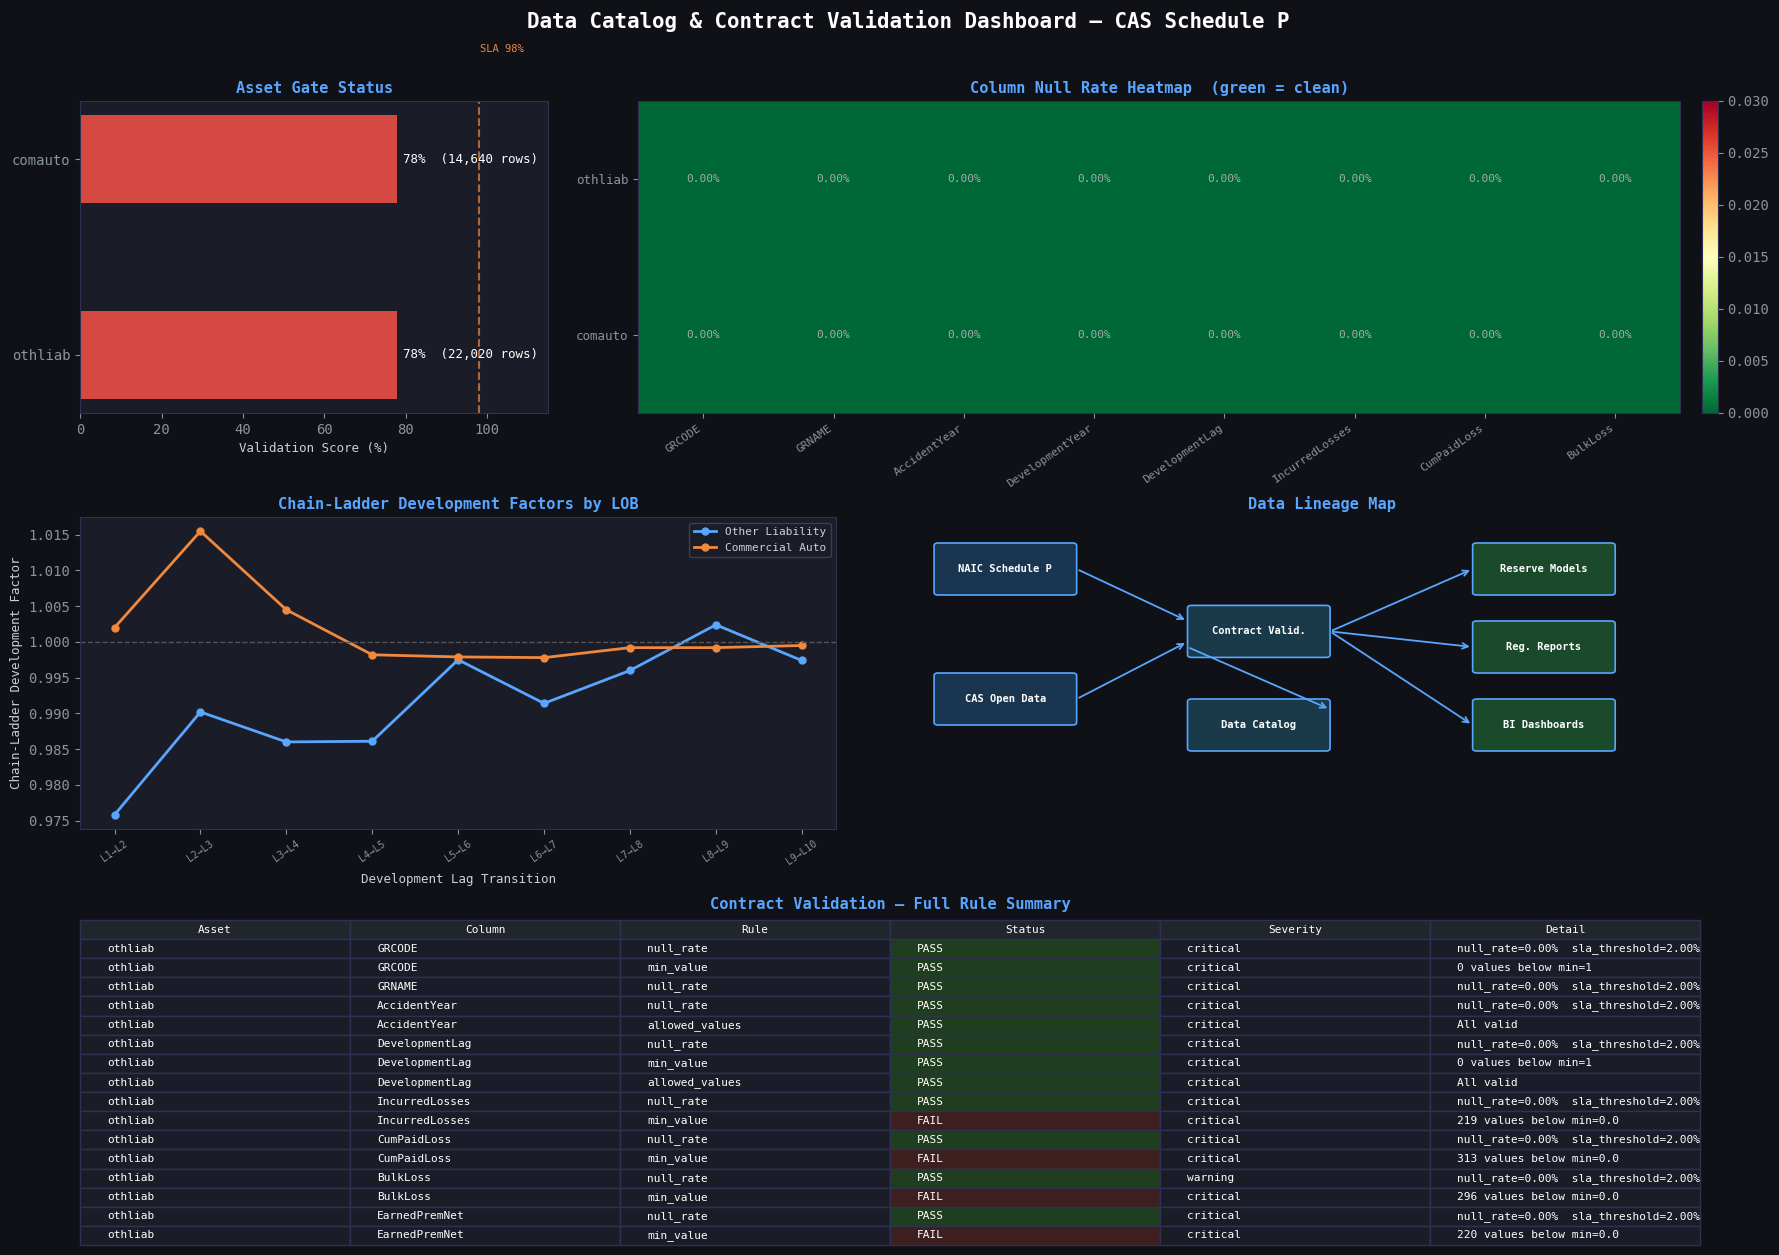

✅ Dashboard saved → outputs/catalog_dashboard.png


In [15]:
import os; os.makedirs('outputs', exist_ok=True)

fig = plt.figure(figsize=(18, 13), facecolor='#0f1117')
fig.suptitle('Data Catalog & Contract Validation Dashboard — CAS Schedule P',
             fontsize=15, fontweight='bold', color='white', y=0.99)

asset_names = list(datasets.keys())

# ── A: Gate scores ────────────────────────────────────────────────────────────
ax1 = fig.add_axes([0.04, 0.68, 0.26, 0.24])
scores = [all_results[a]['gate']['score'] * 100 for a in asset_names]
cols   = [GREEN if all_results[a]['gate']['gate_status'].startswith('✅') else RED
          for a in asset_names]
bars = ax1.barh(asset_names, scores, color=cols, height=0.45, alpha=0.85)
ax1.set_xlim(0, 115)
ax1.set_xlabel('Validation Score (%)', fontsize=9)
ax1.set_title('Asset Gate Status', fontsize=11, color=ACCENT, fontweight='bold')
for bar, sc, a in zip(bars, scores, asset_names):
    rc = datasets[a].shape[0]
    ax1.text(sc + 1.5, bar.get_y() + bar.get_height()/2,
             f'{sc:.0f}%  ({rc:,} rows)', va='center', fontsize=9, color='white')
ax1.axvline(x=98, color=ORANGE, linewidth=1.5, linestyle='--', alpha=0.7)
ax1.text(98.3, 1.55, 'SLA 98%', color=ORANGE, fontsize=7.5)

# ── B: Null rate heatmap ──────────────────────────────────────────────────────
ax2 = fig.add_axes([0.35, 0.68, 0.60, 0.24])
null_df = pd.DataFrame({a: datasets[a].isnull().mean() for a in asset_names}).T.fillna(0)
has_nulls = null_df.columns[(null_df > 0).any()]
if len(has_nulls) == 0:
    has_nulls = null_df.columns[:8]
null_plot = null_df[has_nulls]
im = ax2.imshow(null_plot.values, aspect='auto', cmap='RdYlGn_r', vmin=0, vmax=0.03)
ax2.set_xticks(range(len(null_plot.columns)))
ax2.set_xticklabels(null_plot.columns, rotation=35, ha='right', fontsize=8)
ax2.set_yticks(range(len(null_plot.index)))
ax2.set_yticklabels(null_plot.index, fontsize=9)
ax2.set_title('Column Null Rate Heatmap  (green = clean)', fontsize=11, color=ACCENT, fontweight='bold')
for i in range(len(null_plot.index)):
    for j in range(len(null_plot.columns)):
        val = null_plot.values[i, j]
        ax2.text(j, i, f'{val:.2%}', ha='center', va='center',
                 fontsize=8, color='white' if val > 0.01 else '#aaa')
plt.colorbar(im, ax=ax2, fraction=0.015, pad=0.02)

# ── C: Loss development curves (chain-ladder) ─────────────────────────────────
ax3 = fig.add_axes([0.04, 0.36, 0.42, 0.24])
lob_colors = {'othliab': ACCENT, 'comauto': ORANGE}
for name, f in factors.items():
    lob = datasets[name]['LineOfBusiness'].iloc[0]
    ax3.plot(range(1, len(f)+1), f.values,
             marker='o', markersize=5, linewidth=2,
             color=lob_colors[name], label=lob)
ax3.axhline(y=1.0, color='#555', linestyle='--', linewidth=1)
ax3.set_xlabel('Development Lag Transition', fontsize=9)
ax3.set_ylabel('Chain-Ladder Development Factor', fontsize=9)
ax3.set_title('Chain-Ladder Development Factors by LOB', fontsize=11, color=ACCENT, fontweight='bold')
ax3.legend(fontsize=8, framealpha=0.2)
ax3.set_xticks(range(1, len(f)+1))
ax3.set_xticklabels([f'L{i}→L{i+1}' for i in range(1, len(f)+1)], rotation=35, fontsize=7)

# ── D: Data lineage map ───────────────────────────────────────────────────────
ax4 = fig.add_axes([0.51, 0.36, 0.44, 0.24])
ax4.set_xlim(0, 10); ax4.set_ylim(0, 6); ax4.axis('off')
ax4.set_title('Data Lineage Map', fontsize=11, color=ACCENT, fontweight='bold')

nodes = [
    (1.0, 5.0, 'NAIC Schedule P',  '#1a3550'),
    (1.0, 2.5, 'CAS Open Data',    '#1a3550'),
    (4.2, 3.8, 'Contract Valid.','#1a3a4a'),
    (4.2, 2.0, 'Data Catalog',      '#1a3a4a'),
    (7.8, 5.0, 'Reserve Models',    '#1a4a2a'),
    (7.8, 3.5, 'Reg. Reports','#1a4a2a'),
    (7.8, 2.0, 'BI Dashboards',     '#1a4a2a'),
]
for (x, y, lbl, col) in nodes:
    ax4.add_patch(mpatches.FancyBboxPatch(
        (x-0.85, y-0.45), 1.7, 0.9,
        boxstyle='round,pad=0.05', facecolor=col, edgecolor='#58a6ff', linewidth=1.2))
    ax4.text(x, y, lbl, ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')

for (x1,y1,x2,y2) in [(1.9,5.0,3.3,4.0),(1.9,2.5,3.3,3.6),
                        (5.1,3.8,6.9,5.0),(5.1,3.8,6.9,3.5),(5.1,3.8,6.9,2.0),
                        (3.3,3.5,5.1,2.3)]:
    ax4.annotate('', xy=(x2,y2), xytext=(x1,y1),
                 arrowprops=dict(arrowstyle='->', color='#58a6ff', lw=1.3))

# ── E: Validation summary table ───────────────────────────────────────────────
ax5 = fig.add_axes([0.04, 0.04, 0.90, 0.25])
ax5.axis('off')
ax5.set_title('Contract Validation — Full Rule Summary', fontsize=11, color=ACCENT, fontweight='bold', pad=8)

rows_tbl = []
for a in asset_names:
    for r in all_results[a]['results']:
        rows_tbl.append([a, r.column, r.rule, r.status, r.severity, r.detail])
tbl_df = pd.DataFrame(rows_tbl, columns=['Asset','Column','Rule','Status','Severity','Detail'])
show_df = tbl_df.head(16)

table = ax5.table(
    cellText=show_df.values, colLabels=show_df.columns,
    cellLoc='left', loc='center', bbox=[0,0,1,1])
table.auto_set_font_size(False)
table.set_fontsize(8)
for (row, col), cell in table.get_celld().items():
    cell.set_facecolor('#1a1d27' if row > 0 else '#21262d')
    cell.set_edgecolor('#2e3250')
    cell.set_text_props(color='white')
    if row > 0 and col == 3:
        cell.set_facecolor('#1f3d1f' if show_df.iloc[row-1]['Status']=='PASS' else '#3d1f1f')

plt.savefig('outputs/catalog_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print("✅ Dashboard saved → outputs/catalog_dashboard.png")


---
## 8 · Export Artifacts

Exporting machine-readable outputs for downstream consumption:
- **Data catalog registry** — asset metadata for discovery tools
- **Data contracts** — formal schema definitions (can be ingested by dbt, Foundry, Great Expectations)
- **Validation audit log** — full rule-check history for compliance / audit trail


In [16]:
import os; os.makedirs('outputs', exist_ok=True)

# 1. Catalog registry
reg = {}
for name, e in catalog.registry.items():
    row = dict(e)
    row['dtypes']     = {k: str(v) for k, v in datasets[name].dtypes.items()}
    row['null_rates'] = {k: round(float(v), 4) for k, v in row['null_rates'].items()}
    reg[name] = row
with open('outputs/data_catalog_registry.json', 'w') as f:
    json.dump(reg, f, indent=2, default=str)

# 2. Contracts
with open('outputs/data_contracts.json', 'w') as f:
    json.dump({c.asset_name: asdict(c) for c in ALL_CONTRACTS}, f, indent=2)

# 3. Validation audit log
rows = []
for a in asset_names:
    for r in all_results[a]['results']:
        g = all_results[a]['gate']
        rows.append({
            'asset': r.asset_name, 'column': r.column, 'rule': r.rule,
            'status': r.status, 'severity': r.severity, 'detail': r.detail,
            'gate_status': g['gate_status'], 'gate_score': g['score'],
            'run_ts': datetime.now().isoformat(),
        })
pd.DataFrame(rows).to_csv('outputs/validation_report.csv', index=False)

# 4. Chain-ladder factors
cld = {}
for name, f in factors.items():
    cld[name] = {'lob': datasets[name]['LineOfBusiness'].iloc[0], 'factors': f.to_dict()}
with open('outputs/chainladder_factors.json', 'w') as f:
    json.dump(cld, f, indent=2)

print("✅ Artifacts exported to outputs/:")
print(f"   data_catalog_registry.json   ({len(reg)} assets)")
print(f"   data_contracts.json          ({len(ALL_CONTRACTS)} contracts)")
print(f"   validation_report.csv        ({len(rows)} rule checks)")
print(f"   chainladder_factors.json     ({len(cld)} LOBs)")


✅ Artifacts exported to outputs/:
   data_catalog_registry.json   (2 assets)
   data_contracts.json          (2 contracts)
   validation_report.csv        (36 rule checks)
   chainladder_factors.json     (2 LOBs)


---
## Summary

This notebook demonstrated an end-to-end **Data Cataloging & Contract Validation** framework on real-world insurance data.

| Component | What Was Built |
|---|---|
| **Real Data** | CAS Schedule P — 36,660 rows across 2 lines of business, 393 insurers |
| **EDA** | Loss distributions, loss ratios, development maturity, IBNR reserves |
| **Chain-Ladder** | Actuarial development factors per line of business |
| **Data Contracts** | Machine-readable schema + SLA + ownership + data citation |
| **Data Catalog** | Automated metadata extraction + asset registry |
| **Contract Validator** | Rule engine: null checks, min value, enum validation |
| **Pipeline Gate** | PASS / BLOCK with full audit trail |
| **Exports** | JSON registry, JSON contracts, CSV audit report, JSON chain-ladder factors |

---

### Data Citation

> Casualty Actuarial Society (CAS) Reserve Research Working Group.  
> *Loss Reserving Data Pulled from NAIC Schedule P with Additional Accident Years.*  
> Data compiled by S&P Global Market Intelligence.  
> Lines of business: Other Liability (occurrence), Commercial Auto/Truck Liability.  
> Accident years 1998–2007. Updated December 2025.  
> Available at: https://www.casact.org/publications-research/research/research-resources/loss-reserving-data-pulled-naic-schedule-p  
> License: Freely available under CAS open data policy.

---

### Applicability Beyond Insurance

The same framework — contracts, catalog, validation gate — applies wherever data governance matters:

- **Banking / FinTech**: transaction data, credit risk inputs
- **Healthcare**: patient records, clinical trial data
- **Retail / Logistics**: inventory, demand forecasting pipelines
- **Any regulated industry**: audit-ready, traceable data flows

---
*Nisrina Afnan Walyadin · nisrinawalyadin@gmail.com · Munich, Germany*  
*MSc Mathematics, Technical University of Munich*
